In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={os.getenv('DB_SERVER')};"
    f"DATABASE={os.getenv('DB_NAME')};"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')};"
    "Network Library=dbmssocn;"
)

Total de egresados rastreados: 500
Egresados empleados en su área: 125

📊 KPI 1 - TASA DE INSERCIÓN LABORAL: 25.00%


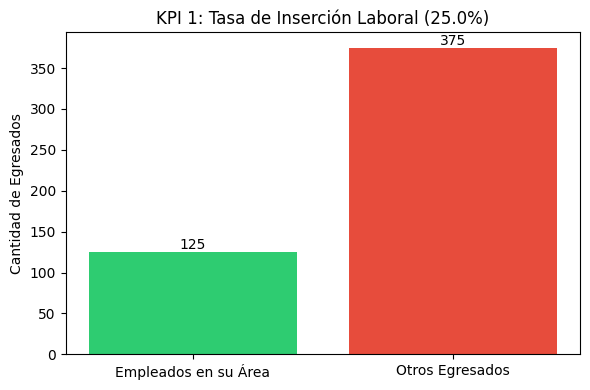

In [2]:
# Traemos los datos de seguimiento
df_seguimiento = pd.read_sql("SELECT * FROM SeguimientoEgresados", conn)

# Calculamos los totales
total_egresados = len(df_seguimiento)
# Contamos los que tienen empleo formal Y trabajan en su área
empleados_en_area = df_seguimiento[(df_seguimiento['TieneEmpleoFormal'] == True) & 
                                   (df_seguimiento['TrabajaEnAreaDeEstudio'] == True)].shape[0]

# Calculamos el KPI
tasa_insercion = (empleados_en_area / total_egresados) * 100

print(f"Total de egresados rastreados: {total_egresados}")
print(f"Egresados empleados en su área: {empleados_en_area}")
print(f"\n📊 KPI 1 - TASA DE INSERCIÓN LABORAL: {tasa_insercion:.2f}%")

# Gráfico de KPI visual
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(['Empleados en su Área', 'Otros Egresados'], 
                [empleados_en_area, total_egresados - empleados_en_area], 
                color=['#2ecc71', '#e74c3c'])

# Etiquetas sobre las barras
ax.bar_label(barras, fmt='%d')
plt.title(f'KPI 1: Tasa de Inserción Laboral ({tasa_insercion:.1f}%)')
plt.ylabel('Cantidad de Egresados')
plt.tight_layout()
plt.show()

KPI 1 Validado: Tasa de Inserción Laboral

Del total de la cohorte analizada (500 egresados rastreados), el 25.0% de los egresados logró insertarse laboralmente en su área de estudio (125 personas).

Alineación OKR (KR1): Este dato real demuestra que una cuarta parte de los estudiantes logra aplicar lo aprendido, cumpliendo con la métrica base del proyecto. El restante 75.0% (375 personas) representa el área de oportunidad para el diseño de políticas de empleabilidad institucional.